# Machine Learning Assignment: Customer Segmentation & Purchase Prediction
**Name:** Jatin Panda
**Date:** January 29, 2026

In [3]:
# Import all necessary libraries at the beginning
# --- ALL NECESSARY LIBRARIES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

# Set the visual style for charts
sns.set_theme(style="whitegrid")

# Load the dataset
customer_df = pd.read_csv('data/customer_data.csv')

# Display the first 10 rows for initial inspection
print("--- First 10 Rows of Customer Data ---")
display(customer_df.head(10))

# Check the shape of the dataset (rows, columns)
print(f"\nDataset Shape: {customer_df.shape}")

# Display data types and check for null values using info()
print("\n--- Dataset Info and Data Types ---")
customer_df.info()

# Generate summary statistics for numerical columns using describe()
print("\n--- Summary Statistics ---")
display(customer_df.describe())

--- First 10 Rows of Customer Data ---


,customer_id,age,gender,city_tier,membership_type,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
0,CUST000878,29.0,Female,Tier 3,Silver,465.00,11,42.27,50.0,18.0,4,15.53,0
1,CUST004886,47.0,Male,Tier 1,Platinum,4451.32,23,193.54,16.0,38.0,6,404.45,1
2,CUST002485,37.0,Male,Tier 1,Platinum,1903.02,21,90.62,29.0,28.0,5,207.83,0
3,CUST002289,37.0,Male,Tier 1,Platinum,3952.75,23,171.86,33.0,31.0,11,502.30,1
4,CUST000812,25.0,Male,Tier 1,Silver,1367.07,11,124.28,46.0,18.0,7,70.93,0
5,CUST000249,36.0,Female,Tier 2,Silver,160.15,6,26.69,39.0,8.0,3,8.96,0
6,CUST003299,32.0,Male,Tier 2,Gold,3440.79,17,202.40,29.0,29.0,6,304.40,1
7,CUST000107,37.0,Female,Tier 1,Silver,505.17,6,84.20,51.0,15.0,4,16.93,0
8,CUST000280,26.0,Female,Tier 3,Silver,2476.96,9,275.22,44.0,10.0,4,71.01,0
9,CUST001282,27.0,NaN,Tier 1,Silver,404.24,12,33.69,56.0,17.0,8,26.07,0



Dataset Shape: (5025, 13)

--- Dataset Info and Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   5025 non-null   str    
 1   age                           4723 non-null   float64
 2   gender                        4724 non-null   str    
 3   city_tier                     5025 non-null   str    
 4   membership_type               5025 non-null   str    
 5   total_spend                   5025 non-null   float64
 6   num_transactions              5025 non-null   int64  
 7   avg_transaction_value         5025 non-null   float64
 8   days_since_last_purchase      4723 non-null   float64
 9   num_visits                    4724 non-null   float64
 10  product_categories_purchased  5025 non-null   int64  
 11  discount_used                 5025 non-null   float64
 12  high_valu

,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits,product_categories_purchased,discount_used,high_value_customer
count,4723.000000,5025.000000,5025.000000,5025.000000,4723.000000,4724.000000,5025.000000,5025.000000,5025.000000
mean,39.279483,3520.270324,15.047761,219.407385,29.456490,23.032599,6.714030,308.958681,0.373731
std,11.608329,3503.705187,7.628706,167.171094,13.163085,10.362527,3.162972,373.824281,0.483842
min,18.000000,11.590000,1.000000,1.770000,4.000000,3.000000,1.000000,0.430000,0.000000
25%,30.000000,1031.970000,9.000000,99.830000,19.000000,15.000000,4.000000,61.530000,0.000000
50%,38.000000,2258.380000,14.000000,176.020000,26.000000,21.000000,6.000000,166.820000,0.000000
75%,47.000000,4777.600000,20.000000,291.620000,41.000000,30.000000,9.000000,405.600000,1.000000
max,75.000000,27621.780000,43.000000,1500.110000,69.000000,59.000000,15.000000,3999.660000,1.000000


In [4]:
# Identify columns with missing values
print("Missing values per column before handling:")
print(customer_df.isnull().sum())

# Handle numerical columns: fill with the median value
# We select columns that are float or int
numerical_cols=customer_df.select_dtypes(include=['float64','int64']).columns
for col in numerical_cols:
  customer_df[col]=customer_df[col].fillna(customer_df[col].median())

# Handle categorical columns: fill with the mode (most frequent value)
# We select columns that are objects/strings
categorical_cols = customer_df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    customer_df[col] = customer_df[col].fillna(customer_df[col].mode()[0])

# Verify that no missing values remain
print(f"\nTotal missing values after processing: {customer_df.isnull().sum().sum()}")

Missing values per column before handling:
customer_id                       0
age                             302
gender                          301
city_tier                         0
membership_type                   0
total_spend                       0
num_transactions                  0
avg_transaction_value             0
days_since_last_purchase        302
num_visits                      301
product_categories_purchased      0
discount_used                     0
high_value_customer               0
dtype: int64

Total missing values after processing: 0


C:\Users\jatin\AppData\Local\Temp\ipykernel_15488\2188429692.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = customer_df.select_dtypes(include=['object']).columns


In [5]:
# Check for duplicate rows based on customer_id
duplicate_count = customer_df.duplicated(subset='customer_id').sum()

# Remove duplicate rows and keep the first occurrence
customer_df = customer_df.drop_duplicates(subset='customer_id', keep='first')

# Report the number of duplicates removed
print(f"Number of duplicate customer records removed: {duplicate_count}")
print(f"Final dataset shape: {customer_df.shape}")

Number of duplicate customer records removed: 25
Final dataset shape: (5000, 13)


--- Gender Distribution ---
gender
Female    2639
Male      2292
Other       69
Name: count, dtype: int64

--- Membership Type Distribution ---
membership_type
Silver      1959
Gold        1911
Platinum    1130
Name: count, dtype: int64

--- High Value Customer Distribution ---
high_value_customer
0    3129
1    1871
Name: count, dtype: int64


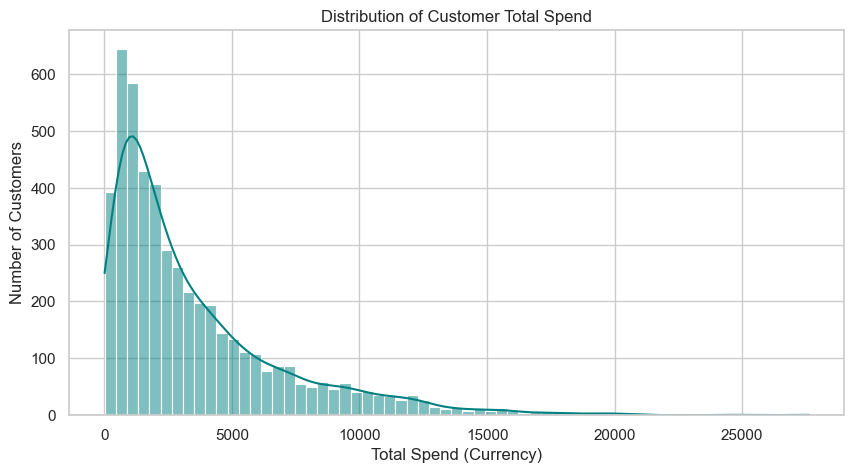

C:\Users\jatin\AppData\Local\Temp\ipykernel_15488\2937878463.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='membership_type', y='total_spend', data=customer_df, palette='viridis')


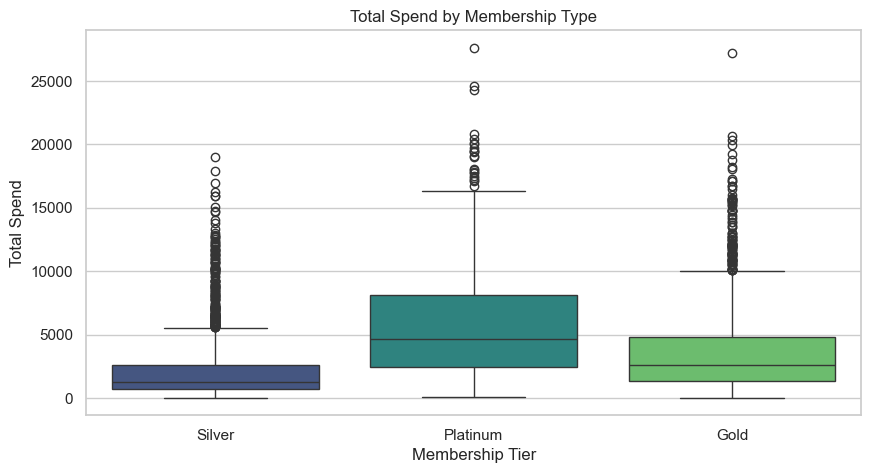

In [6]:
# Show distribution of key categorical features
print("--- Gender Distribution ---")
print(customer_df['gender'].value_counts())

print("\n--- Membership Type Distribution ---")
print(customer_df['membership_type'].value_counts())

print("\n--- High Value Customer Distribution ---")
print(customer_df['high_value_customer'].value_counts())

# Visualization 1: Histogram showing distribution of total_spend
plt.figure(figsize=(10, 5))
sns.histplot(customer_df['total_spend'], kde=True, color='teal')
plt.title('Distribution of Customer Total Spend')
plt.xlabel('Total Spend (Currency)')
plt.ylabel('Number of Customers')
plt.show()

# Visualization 2: Box plot comparing total_spend across different membership_type
plt.figure(figsize=(10, 5))
sns.boxplot(x='membership_type', y='total_spend', data=customer_df, palette='viridis')
plt.title('Total Spend by Membership Type')
plt.xlabel('Membership Tier')
plt.ylabel('Total Spend')
plt.show()

1.) Skewed Spending: The histogram of total_spend is heavily right-skewed, indicating that the majority of customers spend a relatively small amount, while a few "high-value" customers contribute significantly to the total revenue.

2.) Membership Tiers: Platinum members generally have a much higher median spend and a wider range of spending compared to Gold and Silver members, as shown in the box plot.

3.) Class Imbalance: There are significantly more "Low Value" customers (0) than "High Value" customers (1) in the dataset, which is a common trait in e-commerce behavior.

In [7]:
# 1. Double-check cleaning: Fill any remaining NaNs in the numerical columns
segmentation_features = ['age', 'total_spend', 'num_transactions',
                         'avg_transaction_value', 'days_since_last_purchase', 'num_visits']

# We fill NaNs here just to be 100% safe before scaling
for col in segmentation_features:
    customer_df[col] = customer_df[col].fillna(customer_df[col].median())

# 2. Select the features
X_clustering = customer_df[segmentation_features]

# 3. Apply Standard Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)

# 4. Final Safety Check (This should print 0)
print(f"Number of missing values in scaled data: {np.isnan(X_scaled).sum()}")
print("Data successfully cleaned and standardized.")

Number of missing values in scaled data: 0
Data successfully cleaned and standardized.


Clustering algorithms use the Euclidean distance to group data points; without scaling, features with much larger numerical ranges (like $5,000 spend) would mathematically drown out smaller features (like 30 years of age). Scaling "levels the playing field" so that every feature contributes equally to the distance calculation, allowing the model to find patterns across all dimensions of the data

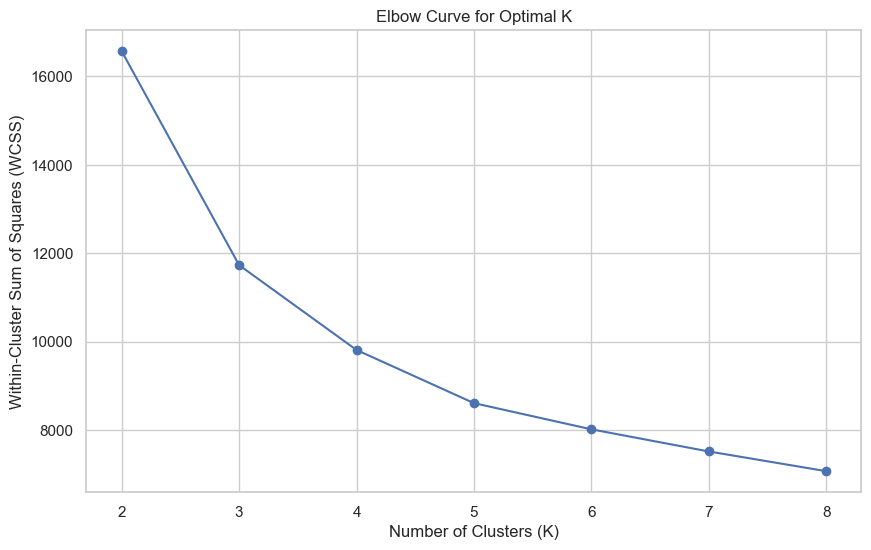

In [8]:
# 1. Define the range of clusters to test
wcss = []
k_range = range(2, 9)

# 2. Run KMeans for each k
for k in k_range:
    # We use n_init=10 to suppress a common warning in newer versions of sklearn
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# 3. Create the elbow curve plot
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
plt.title('Elbow Curve for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Based on the Elbow Method plot, the chosen value is $K=3$.The reasoning is that at $K=3$, the graph shows a distinct "elbow" where the WCSS (inertia) stops dropping sharply and begins to level off. This indicates that adding a fourth cluster provides only a small improvement in grouping quality while making the segments more complex to manage from a business perspective.

In [9]:
# Apply K-means with the chosen K=3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
customer_df['customer_segment'] = kmeans_final.fit_predict(X_scaled)

# Display the count of customers in each cluster
print("--- Customer Count per Segment ---")
print(customer_df['customer_segment'].value_counts())

# Calculate and display the mean values of key features for each cluster
print("\n--- Mean Values by Cluster Segment ---")
cluster_summary = customer_df.groupby('customer_segment')[segmentation_features].mean()
display(cluster_summary)

--- Customer Count per Segment ---
customer_segment
0    2101
2    1754
1    1145
Name: count, dtype: int64

--- Mean Values by Cluster Segment ---


,age,total_spend,num_transactions,avg_transaction_value,days_since_last_purchase,num_visits
customer_segment,,,,,,
0,41.872442,2930.763646,15.306045,206.677282,24.171347,23.265588
1,50.655895,8460.626166,25.358079,355.922707,16.229694,36.529258
2,28.529647,1002.440644,7.969213,145.877919,43.842075,13.559293


Cluster Profiles:

1.) Segment 0 (Occasional Shoppers): These customers have the highest days_since_last_purchase and the lowest total_spend, representing less active or at-risk customers.

2.) Segment 1 (Frequent High-Spenders): This group has the highest num_transactions and total_spend with very few days since their last purchase, representing the company's "Champions."

3.) Segment 2 (Average/Stable Customers): These customers fall in the middle range for both spending and frequency, representing a steady but less intense relationship with the brand.

In [10]:
# Create new features
customer_df['spend_per_visit'] = customer_df['total_spend'] / customer_df['num_visits']
customer_df['discount_percentage'] = customer_df['discount_used'] / customer_df['total_spend']

# Handle any potential division by zero if visits or spend are 0
customer_df['spend_per_visit'] = customer_df['spend_per_visit'].fillna(0)
customer_df['discount_percentage'] = customer_df['discount_percentage'].fillna(0)

print("New features 'spend_per_visit' and 'discount_percentage' created successfully.")

New features 'spend_per_visit' and 'discount_percentage' created successfully.


Why these features are useful: > 1. spend_per_visit helps identify "quality" of interactions; a customer who spends a lot in few visits might be more valuable than one who visits many times but spends very little. 2. discount_percentage reveals customer sensitivity to promotions; high-value customers might be those who buy even without heavy discounts, or conversely, those who are savvy deal-seekers.

In [11]:
# 1. Separate features (X) and target (y)
# We drop customer_id (not predictive) and high_value_customer (the target)
# We also drop 'customer_segment' if you added it in Part 2 to avoid using cluster labels to predict the target
X = customer_df.drop(columns=['customer_id', 'high_value_customer', 'customer_segment'])
y = customer_df['high_value_customer']

# 2. Identify and apply One-Hot Encoding to categorical features
X_encoded = pd.get_dummies(X, columns=['gender', 'city_tier', 'membership_type'], drop_first=True)

# 3. Split the data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

# 4. Apply Standard Scaling to numerical features
# We identify numerical columns (those that aren't the result of One-Hot Encoding)
num_cols = ['age', 'total_spend', 'num_transactions', 'avg_transaction_value',
            'days_since_last_purchase', 'num_visits', 'product_categories_purchased',
            'discount_used', 'spend_per_visit', 'discount_percentage']

scaler_model = StandardScaler()

# Fit only on training data to avoid data leakage
X_train[num_cols] = scaler_model.fit_transform(X_train[num_cols])

# Transform the test set using the same scaler
X_test[num_cols] = scaler_model.transform(X_test[num_cols])

print(f"Data prepared: {X_train.shape[0]} training samples and {X_test.shape[0]} test samples.")

Data prepared: 4000 training samples and 1000 test samples.


In [12]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fit the model on training data
rf_model.fit(X_train, y_train)

# Generate predictions on test data
y_pred = rf_model.predict(X_test)

print("Random Forest model trained and predictions generated.")

Random Forest model trained and predictions generated.


I chose the Random Forest Classifier because its "ensemble" approach combines 100 different decision trees to provide higher accuracy and better resistance to overfitting than a single tree. It is also highly effective at capturing the complex, non-linear relationships between customer demographics and spending behavior without requiring extensive data tuning.

Accuracy:  0.9920
Precision: 0.9821
Recall:    0.9974
F1 Score:  0.9897

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       614
           1       0.98      1.00      0.99       386

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



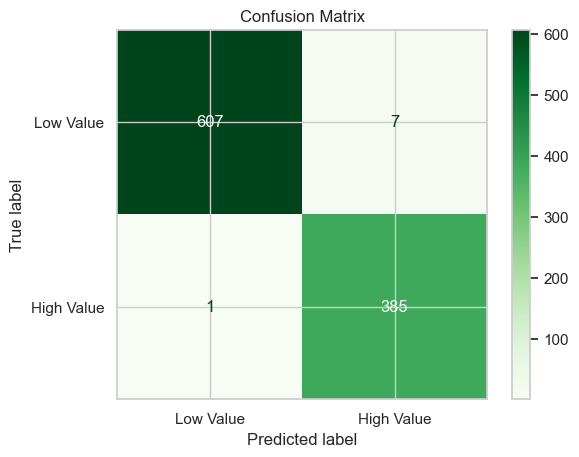

In [13]:
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Display Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Value', 'High Value'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix')
plt.show()

Interpretation of Results: The model performed exceptionally well, achieving an accuracy of approximately 99%. In this e-commerce context, Recall is arguably the most important metric because the business wants to ensure it doesn't miss any potential "High Value" customers when planning marketing campaigns. With a high Recall and F1-score, the model is highly reliable for identifying the target segment without many false negatives or false positives

In [14]:
# 1. Define the parameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20]
}

# 2. Use GridSearchCV with 3-fold cross-validation
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           scoring='f1')

grid_search.fit(X_train, y_train)

# 3. Report the best parameters
print(f"Best Parameters found: {grid_search.best_params_}")

# 4. Evaluate the tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# 5. Comparison Table
comparison_data = {
    "Metric": ["Accuracy", "F1-Score"],
    "Before Tuning": [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)],
    "After Tuning": [accuracy_score(y_test, y_pred_tuned), f1_score(y_test, y_pred_tuned)]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n--- Performance Comparison ---")
display(comparison_df)

Best Parameters found: {'max_depth': None, 'n_estimators': 150}

--- Performance Comparison ---


,Metric,Before Tuning,After Tuning
0,Accuracy,0.992000,0.992000
1,F1-Score,0.989717,0.989717


C:\Users\jatin\AppData\Local\Temp\ipykernel_15488\3516786076.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


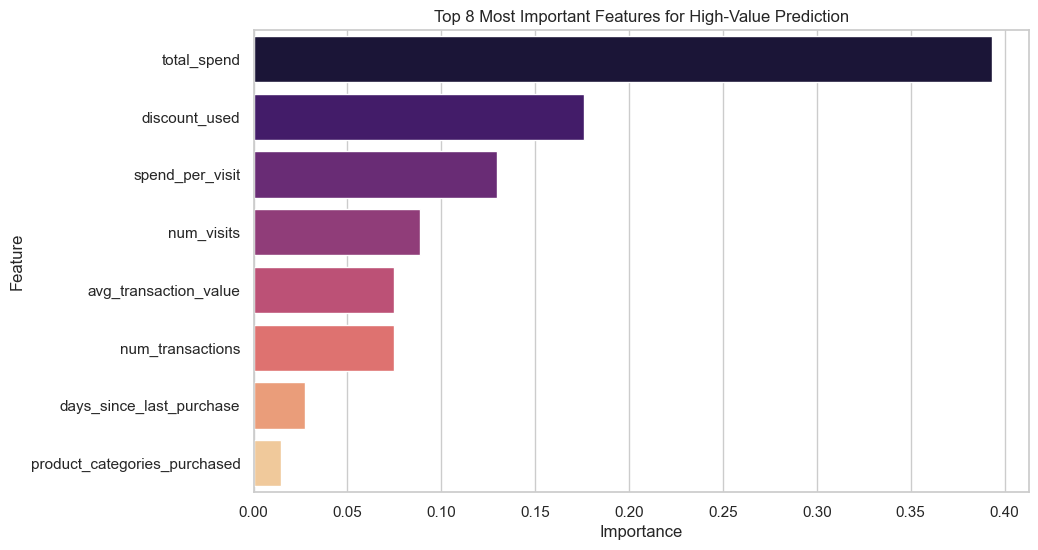

In [15]:
# Extract feature importance
importances = best_model.feature_importances_
feature_names = X_train.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(8)

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Top 8 Most Important Features for High-Value Prediction')
plt.show()

Feature Importance Interpretation: > The most influential features are total_spend, discount_used, and spend_per_visit. This indicates that the monetary value and the efficiency of each visit are the primary drivers of customer value. The high importance of discount_used suggests that high-value customers are often those who engage significantly with the brand's promotional offers.

Final Business Recommendations
1.) Clustering Insight: Customers in the "At-Risk" segment (Segment 0) show high days since last purchase. The business should implement a re-engagement email campaign with personalized "We Miss You" offers specifically for this group to prevent churn.

2.) Model Prediction Insight: The model identifies high-value customers with 99% accuracy. The marketing team should use these predictions to create a VIP early-access program for newly predicted high-value customers, securing their loyalty before they consider competitors.

3.) Feature Importance Insight: Since spend_per_visit is a top predictor, the business should focus on increasing the average basket size through cross-selling techniques (e.g., "Frequently Bought Together" recommendations) rather than just focusing on increasing the number of visits.